<a href="https://colab.research.google.com/github/Malki9/3601763_BD2/blob/main/3601763_BD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries

In [6]:
# Import the required libaries
import pandas as pd
import numpy as np
import json
import re
import plotly.express as px
import nltk

### Load the Dataset

In [7]:
# Create variables and load the .csv datasets
products = pd.read_csv('/content/products.csv')
reviews = pd.read_csv('/content/reviews.csv')
users = pd.read_csv('/content/users.csv')

In [8]:
# Read the file and try to parse it line-by-line manually to avoid 'Trailing data' errors
products_list = []
with open('/content/jcpenney_products.json', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                products_list.append(json.loads(line))
            except json.JSONDecodeError:
                # If a single line fails, it might be the start/end of a standard array
                continue

if not products_list:
    # If line-by-line failed, try reading the whole file as one array
    with open('/content/jcpenney_products.json', 'r') as f:
        jcpenney_products = pd.DataFrame(json.load(f))
else:
    jcpenney_products = pd.DataFrame(products_list)

# Load reviewers (usually works fine with lines=True)
jcpenney_reviewers = pd.read_json('/content/jcpenney_reviewers.json', lines=True)

print('Data loaded successfully')

Data loaded successfully


In [9]:
jcpenney_reviewers.head(4)

,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."


In [10]:
jcpenney_products.head(4)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."


In [11]:
jcpenney_products.head(4)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."


In [12]:
jcpenney_reviewers.head(4)

,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."


In [13]:
reviews.head(4)

,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...


In [14]:
products.head(4)

,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500


In [15]:
users.head(4)

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida


### Data Exploration and Data Cleaning



In [17]:
# check the dataframes basic information like the datatype
users.info()
jcpenney_products.info()
jcpenney_reviewers.info()
products.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniq_id                 7982 non-null   object 
 1   sku                     7982 non-null   object 
 2   name_title              7982 non-null   object 
 3   description             7982 non-null   object 
 4   list_price              7982 non-null   object 
 5   sale_price              7982 non-null   object 
 6   category                7982 non-null   object 
 7   category_tree           7982 non-null   object 
 8   average_product_rati

In [18]:
# Change the datatype of the list_price and the sale_price in the product_review
jcpenney_products['sale_price'] = pd.to_numeric(jcpenney_products['sale_price'], errors='coerce')
jcpenney_products['list_price'] = pd.to_numeric(jcpenney_products['list_price'], errors='coerce')

In [19]:
''' Sometimes the some attributes/ columns has nan which are considered to be string values and hence they are not counted as null. Need to eliminate those as well.
This happens for attributes which are object. Note that an object can be of type list, dictionary, strings. We can see that Reviewed, Reviews, Bought with columns/attributes
in the datasets are type of list, dictionary, list respectively. So we need to identify the list, dictionaries which are empyty '''

# Create a dictionary of dataset
datasets = {
    'users': users,
    'jcpenney_products': jcpenney_products,
    'jcpenney_reviewers': jcpenney_reviewers,
    'products': products,
    'reviews': reviews
}
# Iterate through each column in each dataset and check the datatype
for dataset_name, dataset in datasets.items():
  for column in dataset.columns:
    # Get the columns of the type object
    if dataset[column].dtype == 'object':
      non_null = None
      for value in dataset[column]:
        if value is not None:
          non_null = value
          break

      # Replace the null value with NaN of string column
      if isinstance(non_null, str):
        dataset[column] = (dataset[column].str.strip().replace('', pd.NA))

      # Replace the null value with Nan of list column
      elif isinstance(non_null, list):
        dataset[column] = dataset[column].apply(lambda x: pd.NA if isinstance(x, list) and len(x) == 0 else x)

        # Replace the null values with Nan of Dictionary column
      elif isinstance(non_null, dict):
        dataset[column] = dataset[column].apply(lambda x: pd.NA if isinstance(x, dict) and len(x) == 0 else x)

    # Replace the null values with Nan of the integer and float datatype
    elif dataset[column].dtype in ['int64', 'float64']:
            dataset[column] = dataset[column].replace('', pd.NA)



In [20]:
# Check for null values in each dataframe as a count
# Display in a tabular format
# Function to create the dataframe consist of column and sum
def null_summary(dataset):
    return pd.DataFrame({
        "column": dataset.columns,
        "sum": dataset.isnull().sum().values
    })

# Create summaries of each dataframe
users_null = null_summary(users)
jc_reviews_null = null_summary(jcpenney_reviewers)
jc_products_null = null_summary(jcpenney_products)
products_null = null_summary(products)
reviews_null = null_summary(reviews)

# Put all in dictionary
tables = {
    "users": users_null,
    "jcpenney_reviews": jc_reviews_null,
    "reviews": reviews_null,
    "jc_products": jc_products_null,
    "products": products_null
}

# Find maximum number of rows
max_rows = max(len(dataset) for dataset in tables.values())

# Pad smaller tables
for name, dataset in tables.items():
    if len(dataset) < max_rows:
        padding = pd.DataFrame({
            "column": [""] * (max_rows - len(dataset)),
            "sum": [""] * (max_rows - len(dataset))
        })
        tables[name] = pd.concat([dataset, padding], ignore_index=True)

# Create final aligned table
final_table = pd.concat(tables, axis=1)

final_table

users     jcpenney_reviews        reviews                 jc_products  \
      column sum           column  sum    column sum                  column   
0   Username   0         Username    0   Uniq_id   0                 uniq_id   
1        DOB   0              DOB    0  Username   0                     sku   
2      State   0            State    0     Score   0              name_title   
3                        Reviewed  971    Review   0             description   
4                                                                 list_price   
5                                                                 sale_price   
6                                                                   category   
7                                                              category_tree   
8                                                     average_product_rating   
9                                                                product_url   
10                                                        product_image_urls   
11                                                                     brand   
12                                                      total_number_reviews   
13                                                                   Reviews   
14                                                               Bought With   

             products        
     sum       column   sum  
0      0      Uniq_id     0  
1     67          SKU    67  
2      0         Name     0  
3    543  Description   543  
4   2166        Price  2166  
5    263     Av_Score     0  
6    636                     
7    636                     
8      0                     
9      0                     
10   157                     
11     0                     
12     0                     
13     0                     
14     0

In [21]:
# Standardizing the column names
# Replace the column name 'Bought With' with to bought_with
products.rename(columns={'Bought With': 'bought_with'}, inplace=True)
# Replace the column names with simple
for dataset_name, dataset in datasets.items():
  for column in dataset.columns:
    dataset.rename(columns={column: column.lower()}, inplace=True)

In [22]:
# The users act as the base dataset which is linked with the jcpenney_reviewers and reviews dataset
# Check the Username column in the users, jcpenny_reviews and reviews dataset follows the same standard
# Define the pattern where the first 04 char are simple letters from a-z and the last for as int from 0-9
pattern = r'^[a-z]{4}[0-9]{4}$'
# Get the unique values in each of the dataset of username columns as a Dictionary
users_username = { 'users' : set(users['username']), # convert the username column to set, eliminate the duplicates
                   'reviews': set(reviews['username']),
                   'jcpenney_reviewers' : set(jcpenney_reviewers['username'])
                   }

# Iterate through each value in the users_username
for key, value in users_username.items():
  invalid_found = False
  for username in value:
    if not re.fullmatch(pattern, username):
      print(f" Invalid username in {key}: {username}")
      invalid_found = True
  if not invalid_found: print(f" All usernames in {key} are in the particular standard")

 All usernames in users are in the particular standard
 All usernames in reviews are in the particular standard
 All usernames in jcpenney_reviewers are in the particular standard


In [23]:
# Check all the username in users are there in the jcpenny reviews
users['username'].isin(jcpenney_reviewers['username']).all()

np.True_

In [24]:
''' Accordingly we can see that the users is the base dataset and all the usernames in users are there in jcpenny_reviews. '''
# Check all the username in jcpenny_reviews there in reviews
jcpenney_reviewers['username'].isin(reviews['username']).all()

np.False_

In [25]:
# Get the count of username not there in reviews
jcpenney_reviewers[~jcpenney_reviewers['username'].isin(reviews['username'])]['username'].count()

np.int64(6)

In [26]:
# check the username which are not in the jcpenny_reviews have empty reviews
non_users= jcpenney_reviewers[~jcpenney_reviewers['username'].isin(reviews['username'])][['username','reviewed']]
non_users

,username,reviewed
373,qzsw4431,<NA>
1349,clar2422,<NA>
1562,eevm2113,<NA>
1869,jbym1321,<NA>
2257,eubf2214,<NA>
2410,djzq3441,<NA>


In [27]:
# Drop the rows in jcpenny_reviews where the non existence usernames of review dataset which are not in the jcpenny_reviews
jcpenney_reviewers = jcpenney_reviewers.drop(non_users.index)

In [28]:
# check for duplicate and print the duplicated rows in both users and jcpenny_reviewers dataset
users_duplicate = users[users.duplicated(subset=['username'], keep=False)]
jcpenney_reviewers_duplicate = jcpenney_reviewers[jcpenney_reviewers.duplicated(subset=['username'], keep=False)]
print(users_duplicate)
print(jcpenney_reviewers_duplicate)

      username         dob       state
731   dqft3311  28.07.1995   Tennessee
2619  dqft3311  03.08.1969  New Mexico
      username         dob       state                            reviewed
731   dqft3311  28.07.1995   Tennessee  [5f280fb338485cfc30678998a42f0a55]
2619  dqft3311  03.08.1969  New Mexico  [571b86d307f94e9e8d7919b551c6bb52]


In [29]:
# Drop the second instance in the of the duplicated username from both the dataset
users = users.drop_duplicates(subset='username', keep='first')
jcpenney_reviewers = jcpenney_reviewers.drop_duplicates(subset='username', keep='first')

In [30]:
# Fill the null values in Reviewed column by matching the username in review dataset#
# Map the username with uniq_id
username_mapping = reviews.groupby('username')['uniq_id'].apply(list)
# Fill the null values in the Reviewed column
jcpenney_reviewers['reviewed'] = jcpenney_reviewers['username'].map(username_mapping) # This fillout the missing unique_id that the users have reviewed including the null

In [31]:
# check the usernames in users are the same in jcpenny_reviews usernames with there common column names


In [32]:
# Get the uniq_id of null sku
uniq_id = jcpenney_products.loc[jcpenney_products['sku'].isnull(), 'uniq_id']
# Check uniq_id in products dataset
match_id = products.loc[(products['uniq_id'].isin(uniq_id) & (products['sku'].isnull()))]
if match_id is not None:
  # Drop the rows in both dataset
  jcpenney_products = jcpenney_products.drop(match_id.index)
  products = products.drop(match_id.index)

In [33]:
# Fill the null rows in description, list_price and sales_price columns with the sku, name_title combination
columns_fill = [('description','description'), ('list_price', 'price'), ('sale_price','av_score')]
for jcpenny_column, products_column in columns_fill:
  # Fill nulls in jcpenney_products and products by propagating non-null values within groups
  jcpenney_products[jcpenny_column] = jcpenney_products.groupby(['sku', 'name_title'])[jcpenny_column].transform(lambda x: x.ffill().bfill())
  products[products_column] = products.groupby(['sku', 'name'])[products_column].transform(lambda x: x.ffill().bfill())

  # Find the rows in Jcpenny data which are still null
  null_jcpenny = jcpenney_products[jcpenney_products[jcpenny_column].isnull()]

  # Iterate through each row to fill from the 'products' dataframe if possible
  for uid, row in null_jcpenny.iterrows():
    id = row['uniq_id']

    # Find matching values in the 'products' dataframe for the current 'uniq_id'
    match_values = products.loc[(products['uniq_id'] == id) & (products[products_column].notnull()), products_column]

    # If a matching non-null value is found, replace the null in 'jcpenney_products'
    if not match_values.empty:
        # Use .item() for safer scalar extraction from a single-element Series
        jcpenney_products.at[uid, jcpenny_column] = match_values.iloc[0].item()

  # After attempting to fill for the current column, identify and drop rows that still have nulls
  # Get 'uniq_id's that are still null in jcpenney_products for the current jcpenny_column
  still_null_jcpenney_ids = jcpenney_products.loc[jcpenney_products[jcpenny_column].isnull(), 'uniq_id'].unique()

  # Get 'uniq_id's that are still null in products for the current products_column
  still_null_products_ids = products.loc[products[products_column].isnull(), 'uniq_id'].unique()

  # Combine unique ids from both dataframes that still have nulls in the respective columns
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))

  # Drop these identified rows from both dataframes based on 'uniq_id'
  jcpenney_products = jcpenney_products[~jcpenney_products['uniq_id'].isin(ids_to_drop_combined)]
  products = products[~products['uniq_id'].isin(ids_to_drop_combined)]

/tmp/ipykernel_61187/2259092200.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  products[products_column] = products.groupby(['sku', 'name'])[products_column].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_61187/2259092200.py:31: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))
/tmp/ipykernel_61187/2259092200.py:31: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))
/tmp/i

In [34]:
final_table

users     jcpenney_reviews        reviews                 jc_products  \
      column sum           column  sum    column sum                  column   
0   Username   0         Username    0   Uniq_id   0                 uniq_id   
1        DOB   0              DOB    0  Username   0                     sku   
2      State   0            State    0     Score   0              name_title   
3                        Reviewed  971    Review   0             description   
4                                                                 list_price   
5                                                                 sale_price   
6                                                                   category   
7                                                              category_tree   
8                                                     average_product_rating   
9                                                                product_url   
10                                                        product_image_urls   
11                                                                     brand   
12                                                      total_number_reviews   
13                                                                   Reviews   
14                                                               Bought With   

             products        
     sum       column   sum  
0      0      Uniq_id     0  
1     67          SKU    67  
2      0         Name     0  
3    543  Description   543  
4   2166        Price  2166  
5    263     Av_Score     0  
6    636                     
7    636                     
8      0                     
9      0                     
10   157                     
11     0                     
12     0                     
13     0                     
14     0

In [35]:
# Fill the null_values in the category, category_tree columns propagating non-null values within groups
jcpenney_products[['category','category_tree']] = jcpenney_products.groupby('sku')[['category','category_tree']].transform(lambda x: x.ffill().bfill())

In [36]:
# Drop the rows where the category column is null
jcpenney_products = jcpenney_products.dropna(subset=['category'])

Note that although we filled our NaN values with forward filling and backwardfilling with the sku and name_title combinations, still there are null values in the columns descriptions, list_price and sales_price which will be eliminated by droping the null values. By dropping the null values in list_price made the null values to zero in descriptions.


In [37]:
# drop the null values in product_image_urls
jcpenney_products = jcpenney_products.dropna(subset=['product_image_urls'])

### Exploratory Data Analysis

##### Review Analysis

In the previous steps we followed the process of validating the data and cleaning the data using methods like propagating and dropping the null values in each of the columns. But we didn't preprocess the review which contains text data. After preprocess the text in the review column we can conduct a sentimental analysis, In which we identify the emotion or the view behind each of the review. Whether its is a positive, neutral or negative.
In here the sentimental analysis is coducted in according to the rule base approcach:
- Rule based sentiment - This involves performing the sentimental analysis using a set of manually crafted rules. This involves use of VADAR.


In [32]:
reviews.head()

,uniq_id,username,score,review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...


In [33]:
# High level summary of the review dataset
reviews.describe()

,score
count,39063.000000
mean,1.487648
std,1.400332
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


According the summary statistics we can see that the score given to each of the products purchased varies between 0 to 5.

In [34]:
# Import NLTK
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

Preprocessing the text in Review column

As you can see in the reviews there are punctuation marks which we need to eliminate which is a part of the text preprocessing

In [34]:
# Get the stopwords from nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Define a function to convert the raw review to sting of words
def review_to_words(raw_review):
    # Remove punctuation and non_letters which are numbers and any characters
    letters_only = re.sub("[^a-zA-Z]", " ", raw_review)
    # Convert to lower case
    words = letters_only.lower().split()
    # Remove stop words
    meaningful_words = [w for w in words if not w in stop_words]

    # Return the list of cleaned reviewed
    return(" ".join(meaningful_words))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
# Apply the function
reviews['clean_review'] = reviews['review'].apply(review_to_words)

In [36]:
# Remove the puntuation marks, numbers and keep only letters
# Use regular expression to find and replace
reviews['review'] = reviews['review'].apply(lambda x: re.sub(r'[^a-zA-Z]', ' ', x)) # Set the pattern to search and replace

In [37]:
# Check a single review from reviews dataset
review_text = reviews['review'][0]
print(review_text)

You never have to worry about the fit   Alfred Dunner clothing sizes are true to size and fits perfectly  Great value for the money 


In [38]:
# Convert the letters to lower
reviews['review'] = reviews['review'].apply(lambda x: x.lower())

Tokenization

In [39]:
# Dowload the puntuation
nltk.download('punkt_tab')
# Import word_tokenize from nltk
from nltk.tokenize import word_tokenize
# Tokenize the review, splitting each sentence in to single tokens
reviews['review'] = reviews['review'].apply(lambda x: nltk.word_tokenize(x))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [40]:
reviews.head()

,uniq_id,username,score,review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,"[you, never, have, to, worry, about, the, fit,..."
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,"[good, quality, fabric, perfect, fit, washed, ..."
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,"[i, do, not, normally, wear, pants, or, capris..."
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,"[i, love, these, capris, they, fit, true, to, ..."
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,"[this, product, is, very, comfortable, and, th..."


Remove stop words

In [41]:
# Search for stop words
# Get the stop word list from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print(stop_words)
len(stop_words)

{'o', 'such', "you've", 'shan', 'yourselves', 'hadn', 'hers', 'own', 'mustn', "we've", 'we', 'his', 'against', "won't", 'was', "she'd", 'or', 'i', 'whom', 'after', 'at', 'an', "they've", 'some', 'did', 'ma', 'through', "couldn't", "doesn't", 'our', 'each', 'is', "you'll", 'from', "wasn't", 'herself', 'for', 'mightn', "don't", 'any', 'had', 'the', "you're", 'itself', 'in', "it'll", 'weren', "i've", 'her', 'hasn', "they're", 'how', "hasn't", 'him', "that'll", "didn't", 'they', 'a', "they'd", 'he', "we'll", 'their', 'about', 'been', "mightn't", "weren't", 'she', 'why', 'who', 'because', 'nor', 'once', 'were', 'm', 'll', "she'll", 'very', 'yours', 'just', 'those', "you'd", 'didn', 'won', 'wouldn', "he's", 'before', 'on', 'theirs', 'themselves', "i'd", 'during', 'under', 'himself', 'only', 'will', 'you', 'am', 'should', 'above', 'as', 'other', 'not', 'them', "they'll", 'most', 'myself', "shan't", 'again', 'of', 'up', 'then', 'now', 'doing', 'ain', 'ourselves', 'd', 'ours', 'this', 's', 've'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


198

We can see that there are 198 stopwords define in the NLTK package


In [42]:
# Search for stop words in the Review. Stop word in python can easily be searched in a set
# Convert the stop words to set
stop_words = set(stopwords.words('english'))

# Remove stopwords from the Review
reviews['review'] = reviews['review'].apply(lambda x: [word for word in x if word not in stop_words]) # This splits the review which are in sentence to word and checks each word is a stop_word

Lemmatization

Lemmatization is considered to be important in a sentimental analysis where we need to understand the text. Lemmatizzation converts the words into the correct dictionary form which consider the meaning and the grammer of the context. While in stemming removes prefixes and suffixes from the word. For example if we consider the below sentence from the review after stop word removal.

"never worry fit alfred dunner clothing sizes true size fits perfectly great value money"

Lemmatized sentence
"never worry fit alfred dunner clothing size true size fit perfectly great value money"

fits --> fit
sizes ---> sizes
which are real worlds

Stemming
never worri fit alfr dunner cloth size true size fit perfectli great valu money

worry --> worri
perfectly --> perfectli
which does not have a real meaning or word


In [43]:
# Import the WortNetLemmatizer
from nltk.stem import WordNetLemmatizer
# Download the wordnet
nltk.download('wordnet')

# Call the function
lemmatizer = WordNetLemmatizer()

# Lemmatizing the review column
reviews['review'] = reviews['review'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [36]:
# Check the review column
reviews.head()

,score,review,clean_review
0,2,You never have to worry about the fit...Alfred...,never worry fit alfred dunner clothing sizes t...
1,1,Good quality fabric. Perfect fit. Washed very ...,good quality fabric perfect fit washed well iron
2,2,I do not normally wear pants or capris that ha...,normally wear pants capris elastic waist decid...
3,0,I love these capris! They fit true to size and...,love capris fit true size comfortable wear pla...
4,3,This product is very comfortable and the fabri...,product comfortable fabric launders well


Now that we have cleaned text reviews. There are rows which can have empty reviews. Therefore it is essential to remove those rows. The review column contains a list of words after the preprocess. In order to identify the rows with the null we rerun the cell 14 which identifies the null value in each of the datatypes and cell 15 which displays the null value count in a tabular format.


In [45]:
# Call the final_table
final_table

users     jcpenney_reviews        reviews                 jc_products  \
      column sum           column  sum    column sum                  column   
0   Username   0         Username    0   Uniq_id   0                 uniq_id   
1        DOB   0              DOB    0  Username   0                     sku   
2      State   0            State    0     Score   0              name_title   
3                        Reviewed  971    Review   0             description   
4                                                                 list_price   
5                                                                 sale_price   
6                                                                   category   
7                                                              category_tree   
8                                                     average_product_rating   
9                                                                product_url   
10                                                        product_image_urls   
11                                                                     brand   
12                                                      total_number_reviews   
13                                                                   Reviews   
14                                                               Bought With   

             products        
     sum       column   sum  
0      0      Uniq_id     0  
1     67          SKU    67  
2      0         Name     0  
3    543  Description   543  
4   2166        Price  2166  
5    263     Av_Score     0  
6    636                     
7    636                     
8      0                     
9      0                     
10   157                     
11     0                     
12     0                     
13     0                     
14     0

Now we can see that the review column has 17 null values. Hence we drop those rows

In [46]:
# Drop the null valuse in the column reviews
reviews = reviews.dropna(subset=['review'])

###### Rule Based Sentiment Analysis (VADER)

After preprocessing the text reviews we can apply the rule based sentiment analysis model(VADER).

In [47]:
# Import SentimentIntensity Analyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the vader_lexicon#
nltk.download('vader_lexicon')

# Create SentimentIntensityAnalyzer object
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [48]:
# Apply the SentimentIntensityAnalyzer to review column and save the sentiment score to a new_column
reviews['sentiment_score'] = reviews['review'].apply(lambda x: sid.polarity_scores(" ".join(x))['compound'])

In [49]:
reviews

,uniq_id,username,score,review,sentiment_score
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,"[never, worry, fit, alfred, dunner, clothing, ...",0.9133
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,"[good, quality, fabric, perfect, fit, washed, ...",0.8807
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,"[normally, wear, pant, capri, elastic, waist, ...",0.8883
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,"[love, capri, fit, true, size, comfortable, we...",0.9153
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,"[product, comfortable, fabric, launders, well]",0.6597
...,...,...,...,...,...
39058,2cc49292b44cc12fe22206440d3e7472,whxp1433,2,"[bedspread, practical, beautiful, weight, perf...",0.8225
39059,2cc49292b44cc12fe22206440d3e7472,kfqi4333,1,"[purchased, wedding, ring, quilt, year, ago, w...",0.9468
39060,2cc49292b44cc12fe22206440d3e7472,bynj4221,0,"[gift, daughter, love, much, also, got, pillow...",0.7964
39061,2cc49292b44cc12fe22206440d3e7472,eawq2222,1,"[purchased, pillow, sham, well, bed, spread, m...",0.9061


In the above code the sentiment_score is calculated using the VADAR polarity_Score() function which it assign this score to each word using its predefined lexicon. Since the reviews are in list of tokens, first the list of tokens is converted to a sentence using the join function and then the VADAR polarity_Score() function is applied. The final sentiment_score is given by the compund_score which is a normalized value between -1 to 1. This compound is calculated using the below equation

$compund = x/ sqrt{ x^2 + 15]$

where:
x = sum of sentiment scores given to each word
15 = constant

In [50]:
# Assign the sentiment label based on the sentiment_score
reviews['sentiment'] = reviews['sentiment_score'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else "neutral"))

Create the actual sentiment using the score where the score range from 0 - 5.
If we classify those score. It will be as below:
*   0-2 --> Negative
*   3 --> Neutral
*   5 --> Positive








In [39]:
# Assign the true sentiment labels
reviews['true_sentiment'] = reviews['score'].apply(lambda x: 'neutral' if x == 3 else ('negative' if x <= 2 else "positive"))

In [40]:
reviews.describe()

,score
count,39063.000000
mean,1.487648
std,1.400332
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


According to the descriptive statistics we can see that there are discrepancy between the numeric score given and the sentiment score expressed within the review text. The mean score is approximately 1.49 which indicates low ratings. But the mean of the sentiment score obtained from the Vader sentiment analyzer is 0.69, which indicates that the textual context of the review is largerly positive. The median sentiment_score of 0.82 illustrates that irespective of the low numeric rating given more than half of the reviews given are strong positive sentiment. This suggests that there are inconsitency with the datasets, this inconsitency is known as label noises which the assigned rating does not accurately reflect the sentiment depicted by the review text. This can be further proved by the confusion Matrix.

Confusion Matrix through heatmap

In [42]:
# confusion matrix
confusion_matrix = pd.crosstab(reviews['true_sentiment'], reviews['sentiment'])
confusion_matrix

KeyError: 'sentiment'

In [41]:
# Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap to visualize the consfusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')

plt.title("Sentiment vs Rating confusion matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.show()


NameError: name 'confusion_matrix' is not defined

<Axes: xlabel='score', ylabel='sentiment_score'>

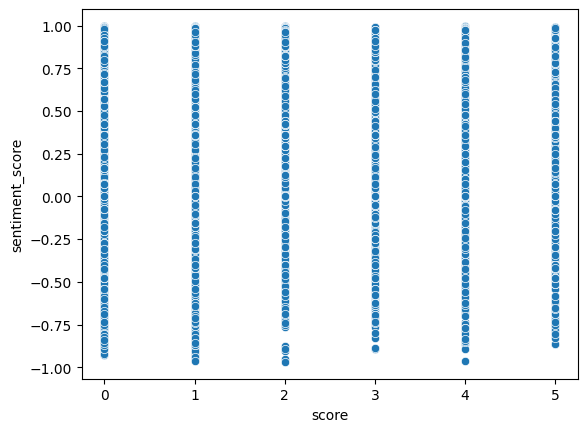

In [55]:
# scatterplot for product_rating vs sentiment_score
sns.scatterplot(data=reviews, x='score', y='sentiment_score')

Calculating the mismatch rate

In [58]:
# Get a column named mismatch label
reviews['mismatch_label'] = (reviews['true_sentiment'] == reviews['sentiment'])

# Calculate the mismatch_rate
mismatch_rate = (reviews['mismatch_label'] == False).sum() / len(reviews) * 100
mismatch_rate

np.float64(86.78288917901851)

Model Performance

Accuracy Score

In [59]:
# Import accuracy score from sklearn
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
accuracy = accuracy_score(reviews['true_sentiment'], reviews['sentiment'])
print("Accuracy_Score",accuracy)

Accuracy_Score 0.13217110820981492


Accordingly we can say that there's a significant mismatch portion between the numerical rating given by each customer and the textual score. This illustrates the misinterpretation of the customer rating scales. In some records the text sentiments says positive but the rating score given is 1 or 2 which illustrates a label noise existences in the dataset. Thus the model score for the sentiment analysis will be lower. Now let's predict the true sentiment of the from the review text, without consdering the score given.


Note that Vader does not consider the context of the text which it will npt give an accurate sentiment. Most of the human language depends on the context and thus its essential to consider the context of the laguage in Natural Language processing.

#### Predicting true sentiment from the review text with ML models

Word Embedding + Neural Network

In [38]:
reviews.head()

,uniq_id,username,score,review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...


In [33]:
# Split the review dataset into train and test
# Create a copy of the review which include only the columns score and review
reviews = reviews[['score', 'review']].copy()

""" According Vader sentiment analysis we found that there is 87% of the mismatch data. Thus the train and test split will be
87% of the mistmatched records will be used as our training and the rest will be our test_data """

# Train/ Test split



In [39]:
# Get the stopwords from nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Define a function to convert the raw review to sting of words
def review_to_words(raw_review):
    # Remove punctuation and non_letters which are numbers and any characters
    letters_only = re.sub("[^a-zA-Z]", " ", raw_review)
    # Convert to lower case
    words = letters_only.lower().split()
    # Remove stop words
    meaningful_words = [w for w in words if not w in stop_words]

    # Return the list of cleaned reviewed
    return(" ".join(meaningful_words))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
# Apply the function
reviews['clean_review'] = reviews['review'].apply(review_to_words)

In [42]:
reviews.head()

,uniq_id,username,score,review,clean_review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,never worry fit alfred dunner clothing sizes t...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,good quality fabric perfect fit washed well iron
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...,normally wear pants capris elastic waist decid...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...,love capris fit true size comfortable wear pla...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...,product comfortable fabric launders well


In [41]:
# Build the word dictionary
vocab = set()

for review in reviews['clean_review']:
  for word in review.split():
    vocab.add(word)

dictionary = {word: i for i, word in enumerate(vocab)}

vocab

{'fimd',
 'windows',
 'writings',
 'ear',
 'charcoal',
 'flucuate',
 'placement',
 'bombards',
 'soothed',
 'hall',
 'injuries',
 'tees',
 'interestingly',
 'stair',
 'quieted',
 'foist',
 'gase',
 'shouldnt',
 'beef',
 'peeking',
 'linsay',
 'colorlooks',
 'sidekick',
 'accepted',
 'sell',
 'sistersgreat',
 'dingy',
 'dependability',
 'predrilled',
 'result',
 'hg',
 'affairs',
 'exciting',
 'revisit',
 'million',
 'princesss',
 'mony',
 'giant',
 'imprint',
 'madden',
 'kettle',
 'inform',
 'dubbed',
 'laceyfor',
 'helpfulness',
 'confidently',
 'discount',
 'countries',
 'stressful',
 'pastor',
 'zip',
 'impact',
 'shop',
 'gorilla',
 'selecting',
 'klear',
 'pedic',
 'waistnipper',
 'grate',
 'french',
 'puchased',
 'greatsize',
 'hallmark',
 'madeand',
 'refill',
 'abilene',
 'piper',
 'watched',
 'plump',
 'amazin',
 'easybasicly',
 'loops',
 'kitchenaid',
 'seventh',
 'struggle',
 'undertone',
 'selectable',
 'thrice',
 'chilled',
 'depended',
 'java',
 'damage',
 'tourister',
 

In [42]:
# Convert each word in the review to numbers
encoded_reviews = []

for review in reviews['clean_review']:
  encoded_reviews.append([dictionary.get(word,0) for word in review])
encoded_reviews

[[9304,
  7631,
  10470,
  7631,
  7363,
  0,
  17355,
  0,
  7363,
  7363,
  0,
  0,
  12686,
  0,
  0,
  0,
  0,
  15770,
  12686,
  7363,
  7631,
  0,
  0,
  0,
  12555,
  9304,
  9304,
  7631,
  7363,
  0,
  12520,
  15770,
  0,
  0,
  120,
  0,
  9304,
  10506,
  0,
  0,
  0,
  0,
  7631,
  0,
  0,
  0,
  7363,
  12555,
  7631,
  0,
  0,
  0,
  0,
  7631,
  0,
  12686,
  0,
  0,
  0,
  0,
  8747,
  7631,
  7363,
  12686,
  7631,
  12520,
  0,
  15770,
  0,
  0,
  10506,
  7363,
  7631,
  0,
  0,
  0,
  10470,
  0,
  15770,
  12555,
  7631,
  0,
  0,
  0,
  9304,
  7631,
  0],
 [10506,
  0,
  0,
  0,
  0,
  11191,
  12555,
  0,
  15770,
  0,
  0,
  0,
  0,
  12686,
  0,
  15406,
  7363,
  0,
  12520,
  0,
  8747,
  7631,
  7363,
  12686,
  7631,
  12520,
  0,
  0,
  12686,
  0,
  0,
  0,
  17355,
  0,
  0,
  120,
  7631,
  0,
  0,
  17355,
  7631,
  15770,
  15770,
  0,
  0,
  7363,
  0,
  9304],
 [9304,
  0,
  7363,
  0,
  0,
  15770,
  15770,
  0,
  0,
  17355,
  7631,
  0,
  736

In [43]:
# Neural Network requires equal- Length input. Thus we pad the reviews to same length
from keras.preprocessing.sequence import pad_sequences

x = pad_sequences(encoded_reviews, maxlen=256, padding = "post", value = 0)

In [44]:
import numpy as np
x = np.array(x)

In [45]:
reviews.head()

,uniq_id,username,score,review,clean_review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,never worry fit alfred dunner clothing sizes t...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,good quality fabric perfect fit washed well iron
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...,normally wear pants capris elastic waist decid...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...,love capris fit true size comfortable wear pla...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...,product comfortable fabric launders well


In [46]:
# Create the target variable
y = reviews['score'].values

In [47]:
# Train/test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
# Build the Word Embedding Model
from keras.models import Sequential
from keras.layers import Embedding, Dense, GlobalAveragePooling1D

vocab_size = len(dictionary) # Ensure the correct input size of 256

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=16))

# Multiple hidden_layers
model.add(GlobalAveragePooling1D())
model.add(Dense(24, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [49]:
model.fit(x, y, epochs=20, batch_size=512, validation_split = 0.1, shuffle =True)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.2932 - loss: -1.7750 - val_accuracy: 0.2969 - val_loss: -15.2152
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2972 - loss: -26.4825 - val_accuracy: 0.2969 - val_loss: -98.5037
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3033 - loss: -140.3389 - val_accuracy: 0.2969 - val_loss: -347.5681
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2971 - loss: -428.0517 - val_accuracy: 0.2969 - val_loss: -841.3242
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3002 - loss: -1001.2416 - val_accuracy: 0.2969 - val_loss: -1677.3402
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3004 - loss: -1878.7262 - val_accuracy: 0.2969 - val_loss: -2904.9529
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2968 - loss: -3205.9104 - val_accuracy: 0.2969 - val_loss: -4616.2769
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.298

In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 16)        │       283,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850,949 (3.25 MB)

 Trainable params: 283,649 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,300 (2.16 MB)

In [52]:
# Predict the true sentiment
y_pred = model.predict(x)

reviews['predicted_sentiment'] = (y_pred > 0.5).astype(int)

1221/1221 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [56]:
reviews.describe()

,score,predicted_sentiment
count,39063.000000,39063.0
mean,1.487648,1.0
std,1.400332,0.0
min,0.000000,1.0
25%,0.000000,1.0
50%,1.000000,1.0
75%,2.000000,1.0
max,5.000000,1.0


Get the rest 17% of the data as the clean label data

In [63]:
clean_dataset  = reviews[reviews['mismatch_label'] == True]
clean_dataset

,uniq_id,username,score,review,sentiment_score,sentiment,true_sentiment,mismatch_label
13,93e5272c51d8cce02597e3ce67b7ad0a,tyfr4414,4,"[like, fabric, polyester, thought, different, ...",0.6124,positive,positive,True
15,93e5272c51d8cce02597e3ce67b7ad0a,oofb2342,4,"[alfred, dunner, great, pant, good, fit, comfo...",0.9153,positive,positive,True
31,505e6633d81f2cb7400c0cfa0394c427,iltp2232,4,"[alfred, dunner, great, pant, good, fit, comfo...",0.9153,positive,positive,True
47,cf73bb2bd93bbd6e1bdf48d399992270,cisr2144,4,"[alfred, dunner, great, pant, good, fit, comfo...",0.9153,positive,positive,True
51,8ffd0ef4fcaf1a82fb514aba5d20e05b,ocfu4332,4,"[good, quality, love, fabric, easy, care, size...",0.9217,positive,positive,True
...,...,...,...,...,...,...,...,...
39025,16e3ca6b6a2d3f5da9a81df6cfe7e27a,vcqh3224,5,"[recently, purchased, vac, wow, powerful, unit...",0.9297,positive,positive,True
39028,16e3ca6b6a2d3f5da9a81df6cfe7e27a,fcnf1412,5,"[found, vacuum, work, well, really, deep, clea...",0.7809,positive,positive,True
39031,209bec04d9f194616358a77d7b41b314,rtbj4421,4,"[hose, short, stretch, clean, vehicle, behind,...",0.0701,positive,positive,True
39039,7a8a7cba7b69b4c46ceac1d9666d84f0,qven4314,5,"[hose, short, stretch, clean, vehicle, behind,...",0.0701,positive,positive,True


Identifying outliers in the numerical data types is essential. Because outliers will distort the analysis. So extreme values should be treated before the analysis.

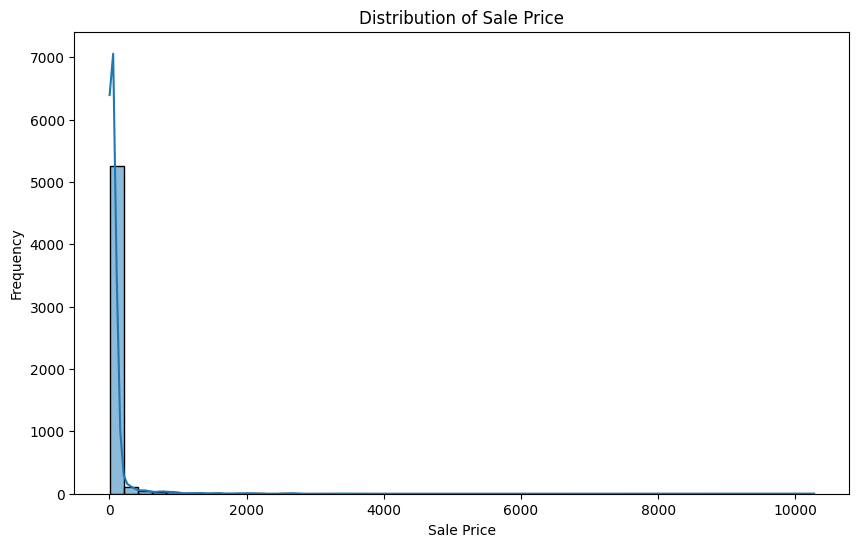

In [ ]:
# Distribution of the sales_price
plt.figure(figsize=(10, 6))
sns.histplot(jcpenney_products['sale_price'], bins = 50, kde =True)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Price")
plt.show()

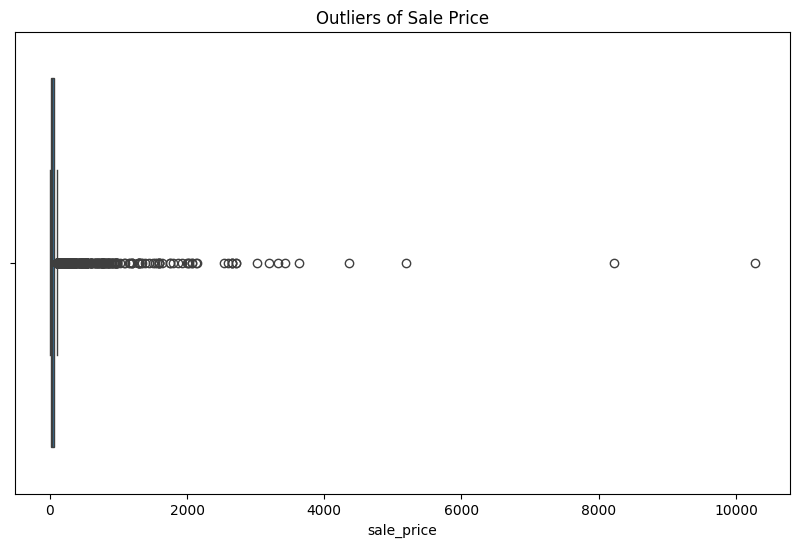

In [ ]:
# Boxplot to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=jcpenney_products['sale_price'])
plt.title("Outliers of Sale Price")
plt.show()

Detect outliers with IQR method

In [ ]:
q1 = jcpenney_products['sale_price'].quantile(0.25)
q3 = jcpenney_products['sale_price'].quantile(0.75)

lower = q1 - 1.5 * (q3 - q1)
upper = q3 + 1.5 * (q3 - q1)

outliers = jcpenney_products[(jcpenney_products['sale_price'] < lower) | (jcpenney_products['sale_price'] > upper)]
outliers

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,reviews,bought with
133,de70462752acc5952fbbf3ca7aab365d,pp5004990211,"American Tourister® iLite Extreme 21"" Spinner ...",With four multi-directional airflow spinner wh...,241.72,120.85,view all luggage,jcpenney|view all luggage,3.000,http://www.jcpenney.com/american-tourister-ili...,http://s7d2.scene7.com/is/image/JCPenney/DP111...,American Tourister,8,"[{'User': 'nfvn3331', 'Review': 'I have wanted...","[a33d2a52525df2ca31fa56f1e3ccd2ce, e73c234ac72..."
170,6b57c2b84e4605f25ee01be296187537,pp5005360367,Mens 3/8 CT. T.W. White and Color-Enhanced Bla...,"Set in sterling silver with grooved detailing,...",936.07,561.64,sale,jcpenney|sale,2.000,http://www.jcpenney.com/mens-38-ct-tw-white-an...,http://s7d2.scene7.com/is/image/JCPenney/DP042...,FINE JEWELRY,1,"[{'User': 'smay1221', 'Review': 'This ring is ...","[0b91df4c7423ee1128558ad1a20b99d7, d797e811feb..."
187,eb2491e25d29f25a40307dd309cd234b,pp5003790546,Cuisinart® Deluxe Convection Toaster Oven Broiler,"Speed up the cook time of breakfast, lunch and...",271.96,189.18,toasters & ovens,jcpenney|toasters & ovens,3.125,http://www.jcpenney.com/cuisinart-deluxe-conve...,http://s7d2.scene7.com/is/image/JCPenney/DP021...,Cuisinart,8,"[{'User': 'hnmq1223', 'Review': 'I PURCHASED T...","[50e97a970ca21f0b5d0e7ca24ec3da85, 9a434f399ad..."
190,96db9fcc49f7d3ed726b0caaf9cf8e5d,pp5006330084,GE® ENERGY STAR® Dishwasher with Stainless Ste...,true Relish an attractive appearance and full ...,965.69,743.75,sale,jcpenney|sale,2.375,http://www.jcpenney.com/ge-energy-star-dishwas...,http://s7d2.scene7.com/is/image/JCPenney/DP111...,GE,8,"[{'User': 'gaqt1134', 'Review': 'I bought this...","[77b6d5531fea4f91af488925230ed69d, 0691fe89701..."
210,e716ce644c28fdbf629ca7a384475e62,pp5004420555,Excelled Belted Jacket,Finish off your cold-weather looks with our as...,574.10,344.45,women's clothing,jcpenney|shops|women's clothing,1.000,http://www.jcpenney.com/excelled-leather-belte...,http://s7d2.scene7.com/is/image/JCPenney/DP081...,Excelled Leather,1,"[{'User': 'msgi1231', 'Review': 'I like the qu...","[43d1651381d17cb7fce9f2b0f620ad20, d113bbc2acf..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7975,0b29fb02ad1499e9429c87ba0c39ccdc,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,vacuums & floorcare,jcpenney|for-the-home|vacuums & floorcare,2.875,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'ursg1434', 'Review': '1) the hose i...","[5efb5f6b6836b228ef44f4e454eae381, 9f4d1f85a84..."
7976,109219fc9372640a443dd3de347ec87f,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,all brands,jcpenney|gift-registry|all brands,3.750,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'irjd2214', 'Review': '1) the hose i...","[b24f6abd57b809892c27e38bd924856f, b38e194a346..."
7977,16e3ca6b6a2d3f5da9a81df6cfe7e27a,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,view all brands,jcpenney|for-the-home|view all brands,3.875,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'cced4433', 'Review': '1) the hose i...","[30611c465e893326b8b676ccc5e9e42b, 799d6290601..."
7978,209bec04d9f194616358a77d7b41b314,pp5002691549,Hoover® WindTunnel® Upright Vacuum Cleaner,This Hoover® vacuum features dual-stage cyclon...,201.97,130.67,sale,jcpenney|for-the-home|sale,3.250,http://www.jcpenney.com/hoover-windtunnel-upri...,http://s7d9.scene7.com/is/image/JCPenney/DP032...,Hoover,8,"[{'User': 'rtbj4421', 'Review': '1) the hose i...","[ac4dcfec

Handle the outliers using log transformation

In [ ]:
import numpy as np
jcpenney_products['sale_price'] = np.log1p(jcpenney_products['sale_price'])

The log transformation has led the skewness to reduce which can be seen by rerunning the distribution and boxplot

Text(0.5, 1.0, 'Distribution of Average Product Rating')

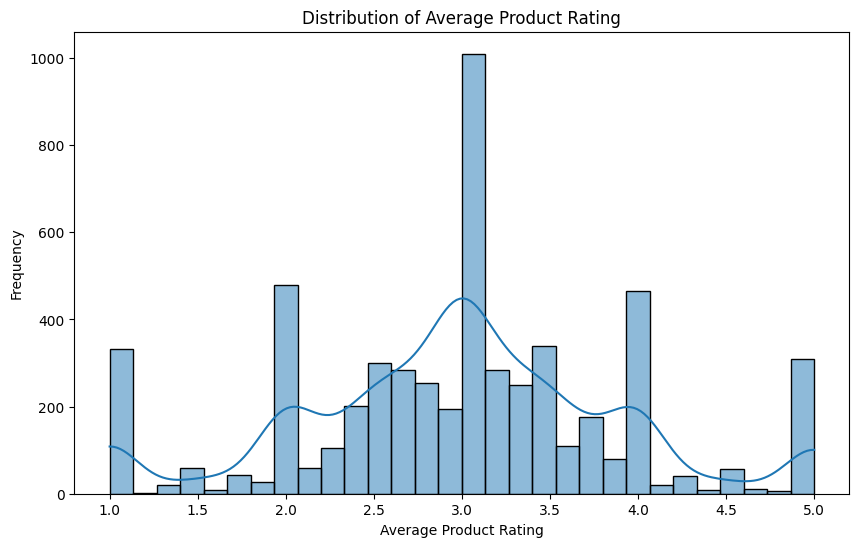

In [ ]:
# distribution of the average_product_rating
plt.figure(figsize=(10, 6))
sns.histplot(jcpenney_products['average_product_rating'], bins=30, kde=True)
plt.xlabel("Average Product Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Average Product Rating")

Text(0.5, 1.0, 'Distribution of Sentiment Score')

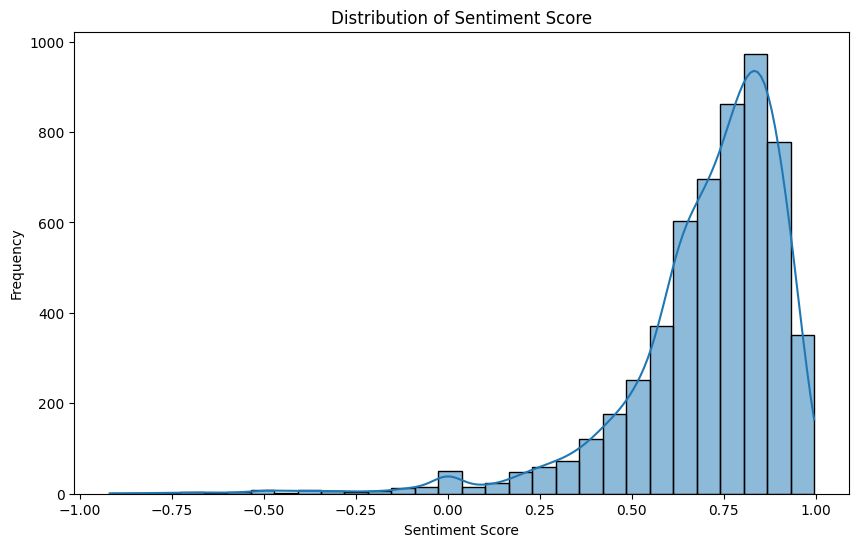

In [ ]:
# distribution of the sentiment_score
plt.figure(figsize=(10, 6))
sns.histplot(jcpenney_products['avg_sentiment_score'], bins=30, kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of Sentiment Score")

#### Geographic Distribution of customers

In [ ]:
# Introduce the state abbrievation for each state which is required by the Plotly
state_abbrev = {
'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
'Wisconsin':'WI','Wyoming':'WY'
}

# Merge reviews with jcpenney_reviewers to link sentiment scores with user state information
user_reviews_sentiment = pd.merge(reviews, jcpenney_reviewers, on='username', how='left')

# Add a column name state_code to user_reviews_sentiment, mapping from its 'state' column
user_reviews_sentiment['state_code'] = user_reviews_sentiment['state'].map(state_abbrev)

# Get the average sentiment score for each state distribution
state_distribution = user_reviews_sentiment.groupby("state_code")["sentiment_score"].mean().reset_index()

fig = px.choropleth(data_frame=state_distribution,
                    locations="state_code",
                    locationmode="USA-states",
                    color="sentiment_score",
                    scope="usa",
                    title = "Average Sentiment Score by State",
                    color_continuous_scale=px.colors.sequential.Reds
)

fig.show()